<a href="https://colab.research.google.com/github/decembersnow1234/DeepLearning_GermanTrafficSign/blob/Portfolio/Projet_Deep_Learning_GTSRB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **GTSRB - German Traffic Sign Recognition Benchmark**

## **1️⃣ - Introduction**


Le German Traffic Sign Recognition Benchmark (GTSRB) est un dataset de référence utilisé dans la classification automatique des panneaux de signalisation.

Avec l’essor des voitures autonomes et des systèmes d’aide à la conduite, il devient de plus en plus important de pouvoir identifier correctement les panneaux de signalisation. Ces panneaux jouent un rôle clé dans **la régulation du trafic** et **la sécurité des usagers**. Si un véhicule ou un système d’assistance ne les interprète pas correctement, cela peut entraîner des erreurs de conduite, comme un dépassement de vitesse involontaire ou un non-respect d’un stop. C’est pourquoi développer un modèle capable de reconnaître et classer automatiquement ces panneaux est essentiel pour assurer une **conduite plus sûre** et mieux **adaptée aux réglementations en vigueur**.

Le dataset GTSRB contient :

- Plus de 50 000 images de panneaux routiers prises dans différentes conditions.
- 43 classes différentes, représentant divers types de panneaux (limitation de vitesse, interdictions, dangers, etc.).
- Des images avec des variations d'éclairage, d’angles et de qualité, rendant la tâche plus proche des conditions réelles sur la route.

**1. Panneaux de limitation de vitesse**

- Ces panneaux indiquent la vitesse maximale autorisée sur une portion de route.
- Exemples : 30 km/h, 50 km/h, 80 km/h, 120 km/h…

**2. Panneaux d’interdiction**
- Ils signalent des actions interdites aux conducteurs.
- Exemples : Sens interdit, interdiction de dépasser, interdiction de tourner…

**3. Panneaux de danger**
- Ils avertissent d’un danger potentiel sur la route.
- Exemples : Route glissante, travaux, passage piéton, virage dangereux…

**4. Panneaux d’obligation**
- Ils imposent un comportement aux conducteurs.
- Exemples : Obligation de tourner à gauche, passage obligatoire, port de chaînes à neige…

**5. Panneaux de priorité**
- Ils régulent les priorités et les intersections.
- Exemples : Stop, cédez-le-passage, priorité à droite, fin de priorité…

### **Importations**

In [2]:
# Installer les bibliothèques nécessaires (uniquement si elles ne sont pas déjà installées)
!pip install --quiet opencv-python-headless matplotlib seaborn tensorflow scikit-learn scikeras

In [3]:
import os
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Traitement des images
import cv2
from PIL import Image

# Préparation des données et division en ensembles
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Construction du modèle CNN
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.regularizers import l2
from scikeras.wrappers import KerasClassifier

# Évaluation du modèle
from sklearn.metrics import classification_report, confusion_matrix
import itertools

# **2️⃣ - Préparation des données**

## **◾ Charger et explorer le dataset GTSRB**

In [4]:
import kagglehub
import os

dataset_path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print("Path to dataset files:", dataset_path)
if not os.path.exists(dataset_path):
    print("Téléchargement du dataset GTSRB...")
    !kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign --force
    print("Extraction du dataset...")
    !unzip gtsrb-german-traffic-sign.zip -d gtsrb_dataset > /dev/null  # Extraction silencieuse
    print("Dataset téléchargé et extrait avec succès.")
else:
    print("Le dataset est déjà présent, aucune action nécessaire.")
dataset_path = "/root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/train"


100%|██████████| 612M/612M [00:27<00:00, 23.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1
Le dataset est déjà présent, aucune action nécessaire.


### **Structure du dataset**

In [ ]:
# Dossier principal
print("Contenu du dossier train :")
print(os.listdir(dataset_path))


Contenu du dossier train :
['13', '11', '10', '22', '38', '5', '8', '27', '12', '9', '40', '37', '16', '29', '18', '1', '24', '0', '39', '33', '35', '21', '17', '34', '30', '32', '26', '19', '25', '2', '6', '41', '28', '42', '14', '23', '31', '3', '20', '15', '36', '4', '7']


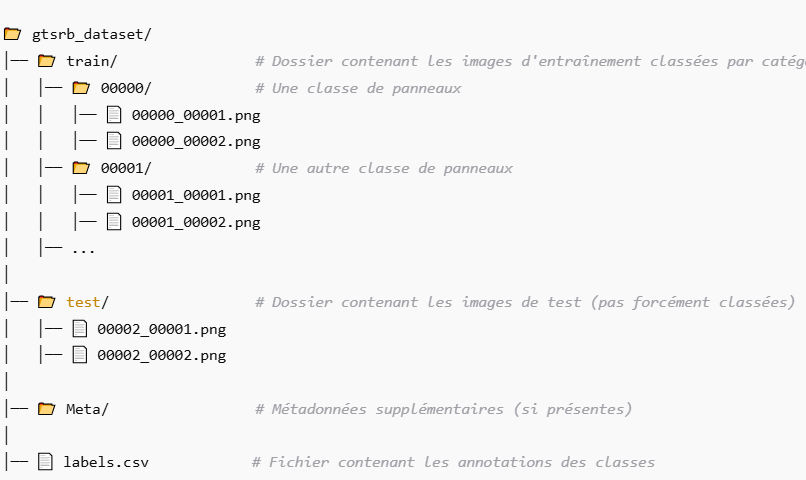

### **◾ Prétraitement des images et division du dataset**

Dans cette section, nous avons chargé et prétraité les images du dataset GTSRB.

Nous avons commencé par récupérer les chemins des images et leurs labels, puis nous avons appliqué des transformations essentielles :
- conversion en RGB
- redimensionnement à une taille uniforme (32x32)
- normalisation des pixels

Enfin, les labels ont été encodés en one-hot afin de les rendre exploitables par notre modèle de deep learning.

In [5]:
#Définition de la taille des images
IMG_SIZE = (32, 32)

#dataset_path = "gtsrb_dataset/train"
image_paths = []
labels = []

#Récupération des chemins des images et des labels
for class_label, class_name in enumerate(sorted(os.listdir(dataset_path))):
    class_dir = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_dir):
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            image_paths.append(img_path)
            labels.append(class_label)

#Chargement des images et prétraitement
X, y = [], []
for img_path, label in zip(image_paths, labels):
    if os.path.exists(img_path):
        img = Image.open(img_path).convert('RGB')  # Conversion en RGB
        img = img.resize(IMG_SIZE)  # Redimensionnement
        X.append(np.array(img))  # Conversion en tableau NumPy
        y.append(label)

#Conversion en tableaux NumPy et normalisation
X = np.array(X) / 255.0  # Normalisation des pixels
y = np.array(y)
y = to_categorical(y, num_classes=len(set(y)))  # Encodage one-hot des labels

print("Shape du dataset:", X.shape, y.shape)


Shape du dataset: (39209, 32, 32, 3) (39209, 43)


### **◾ Augmentation des données**

Nous avons appliqué une augmentation des données sur l'ensemble d'entraînement pour améliorer la robustesse du modèle. Des transformations comme des rotations, translations et zooms ont été utilisées pour simuler des conditions variées.

Ensuite, nous avons séparé les données en entraînement et validation (80%-20%) et appliqué ces transformations uniquement sur l'entraînement

In [6]:
# Définition de l'augmentation des données
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Séparation en ensembles d'entraînement
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

it_train = datagen.flow(X_train, y_train, batch_size=64) # Application de l'augmentation uniquement sur l'entraînement

# Affichage des dimensions des ensembles
print("Ensemble d'entraînement:", X_train.shape, y_train.shape)

Ensemble d'entraînement: (31367, 32, 32, 3) (31367, 43)


# **3️⃣ - Conception et implémentation du modèle CNN**

## **◾ Implémentation d’un Modèle CNN Simple**

- Nous avons défini un modèle CNN simple avec deux couches de convolution et de pooling pour extraire les caractéristiques, suivies d'une couche dense et d'un dropout pour limiter le sur-apprentissage.

- La sortie softmax permet de classer les images en 43 catégories.

- Le modèle est compilé avec l'optimiseur Adam et une perte cross-entropy.

In [34]:
model_simple = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.25),
    Dense(43, activation='softmax')
])

model_simple.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model_simple.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 43)                  │           2,795 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 169,707 (662.92 KB)

 Trainable params: 169,707 (662.92 KB)

 Non-trainable params: 0 (0.00 B)

**➡️ Analyse** :

Le modèle simple est une architecture CNN légère avec environ **169 707 paramètres**, combinant deux couches convolutionnelles suivies de MaxPooling et d’une couche dense.

Il est rapide à entraîner mais peut manquer de profondeur pour capturer des caractéristiques complexes du dataset GTSRB. Des ajustements comme l'ajout de couches ou la normalisation pourraient améliorer ses performances.

## **◾ Implémentation d’un Modèle CNN Avancée**

- Nous avons défini un modèle CNN avancé intégrant des couches de normalisation batch (Batch Normalization) et de régularisation (Dropout) pour améliorer la stabilité et la généralisation.

- Il est composé de trois blocs convolutionnels suivis de pooling, avant d’être aplati et connecté à une couche dense.

- Un ajustement dynamique du taux d’apprentissage et un early stopping ont été ajoutés pour optimiser l'entraînement.

- Le modèle est compilé avec l’optimiseur Adam et une perte cross-entropy

In [8]:
from keras.models import Sequential
from keras.layers import Conv2D, BatchNormalization, Dropout, MaxPooling2D, Flatten, Dense
from keras.regularizers import l2
#from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import LearningRateScheduler

def lr_schedule(epoch, lr):
    return lr * 0.9 if epoch > 5 else lr


lr_callback = LearningRateScheduler(lr_schedule)


# Define Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


# Define CNN Model with Batch Normalization

model_advanced = Sequential([

      Conv2D(32, (5,5), activation='relu', padding="same",  input_shape=(32, 32, 3)),
      BatchNormalization(),  # Added Batch Normalization
      Dropout(0.1),
      MaxPooling2D(2,2),

      Conv2D(64, (3,3), activation='relu', padding="same"),
      BatchNormalization(),
      Dropout(0.2),
      MaxPooling2D(2,2),

      Conv2D(128, (3,3), activation='relu', padding="same"),
      BatchNormalization(),
      Dropout(0.2),
      MaxPooling2D(2,2),

      Flatten(),
      Dense(64, activation='relu'),
      BatchNormalization(),
      Dropout(0.4),
      Dense(y.shape[1], activation='softmax')  # Output layer with num_classes
  ])

# Compile the model
model_advanced.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

model_advanced.summary()  # Print model structure

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 32)          │           2,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │         131,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 43)                  │           2,795 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 229,867 (897.92 KB)

 Trainable params: 229,291 (895.67 KB)

 Non-trainable params: 576 (2.25 KB)

**➡️ Analyse :**

L’analyse du summary du modèle avancé montre une architecture plus profonde avec Batch Normalization, Dropout et trois blocs convolutionnels, améliorant la stabilité et la généralisation. texte en gras

Avec **229 867 paramètres**, il est plus robuste que le modèle simple tout en limitant le sur-apprentissage.

# **4️⃣ - Entraînement du modèle**

### **◾ Training modèle simple**

Nous avons entraîné le modèle CNN simple sur l'ensemble d'entraînement, en utilisant une validation croisée pour suivre son évolution sur un ensemble de validation.

L'apprentissage s'est déroulé sur 10 époques avec un batch de 64 images par itération.

In [35]:
history_simple = model_simple.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=10,
                    batch_size=64)

Epoch 1/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.2741 - loss: 2.7290 - val_accuracy: 0.8304 - val_loss: 0.6624
Epoch 2/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7569 - loss: 0.7954 - val_accuracy: 0.9264 - val_loss: 0.2797
Epoch 3/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8565 - loss: 0.4489 - val_accuracy: 0.9597 - val_loss: 0.1616
Epoch 4/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9038 - loss: 0.3149 - val_accuracy: 0.9693 - val_loss: 0.1351
Epoch 5/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9203 - loss: 0.2674 - val_accuracy: 0.9784 - val_loss: 0.0960
Epoch 6/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9370 - loss: 0.2125 - val_accuracy: 0.9774 - val_loss: 0.0828
Epoch 7/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9432 - loss: 0.1741 - val_accuracy: 0.9833 - val_loss: 0.0754
Epoch 8/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9488 - loss: 0.1577 - val_accuracy: 0

**➡️ Analyse :**

L'entraînement du modèle simple montre une **progression rapide** de la précision, atteignant **96.8%** en entraînement et **98.9%** en validation après **10 époques**.

La **perte diminue constamment**, indiquant une bonne convergence. Cependant, l'écart entre la précision d'entraînement et de validation peut suggérer un début de **sur-apprentissage**, ce qui nécessiterait une analyse plus approfondie avec des techniques de régularisation ou de validation croisée.

### **◾ Training modèle avancée : Sans augmentation de données**

Nous avons entraîné le modèle avancé sur 20 époques avec un batch de 64 images, sans augmentation de données, en intégrant un early stopping et un ajustement dynamique du taux d’apprentissage pour optimiser la convergence et éviter le sur-apprentissage

In [ ]:
# Train the Model
history_advanced = model_advanced.fit(
    X_train, y_train, batch_size = 64,
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[early_stopping, lr_callback]
)

Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.1321 - loss: 3.7000 - val_accuracy: 0.3805 - val_loss: 2.7245 - learning_rate: 1.0000e-04
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4731 - loss: 2.0532 - val_accuracy: 0.7052 - val_loss: 1.1818 - learning_rate: 1.0000e-04
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6484 - loss: 1.3502 - val_accuracy: 0.8337 - val_loss: 0.7559 - learning_rate: 1.0000e-04
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7656 - loss: 0.9364 - val_accuracy: 0.9068 - val_loss: 0.4771 - learning_rate: 1.0000e-04
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8435 - loss: 0.6642 - val_accuracy: 0.9439 - val_loss: 0.3407 - learning_rate: 1.0000e-04
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8896 - loss: 0.4963 - val_accuracy: 0.9656 - val_loss: 0.2338 - learning_rate: 1.0000e-04
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy

**➡️ Analyse :**

L'entraînement du modèle avancé sans augmentation de données montre une amélioration progressive avec une accuracy d’entraînement atteignant **99.02%** et une validation à **99.64%** après 20 époques.

La perte diminue régulièrement, indiquant une bonne convergence.

L'ajustement dynamique du taux d’apprentissage a probablement aidé à optimiser l’entraînement.

Cependant, la faible différence entre l’accuracy d’entraînement et de validation suggère que le modèle pourrait être proche du sur-apprentissage.

### **◾ Training modèle avancée : Avec augmentation de données**

Nous avons entraîné le modèle avancé avec augmentation de données pour améliorer sa robustesse face aux variations d’images.

L'entraînement s’est déroulé sur 20 époques avec un early stopping et un ajustement dynamique du taux d’apprentissage pour optimiser la convergence

In [ ]:
# Train the Model
history_advanced_data_augmented = model_advanced.fit(
    it_train, #Augmentation de données
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[early_stopping, lr_callback]
)

Epoch 1/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 29s 44ms/step - accuracy: 0.0639 - loss: 4.0351 - val_accuracy: 0.1649 - val_loss: 3.3206 - learning_rate: 1.0000e-04
Epoch 2/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.1738 - loss: 3.2167 - val_accuracy: 0.3814 - val_loss: 2.2692 - learning_rate: 1.0000e-04
Epoch 3/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.2775 - loss: 2.7131 - val_accuracy: 0.4730 - val_loss: 1.8067 - learning_rate: 1.0000e-04
Epoch 4/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.3513 - loss: 2.3661 - val_accuracy: 0.5186 - val_loss: 1.5678 - learning_rate: 1.0000e-04
Epoch 5/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.4127 - loss: 2.0632 - val_accuracy: 0.5715 - val_loss: 1.3674 - learning_rate: 1.0000e-04
Epoch 6/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.4523 - loss: 1.8903 - val_accuracy: 0.6187 - val_loss: 1.2123 - learning_rate: 1.0000e-04
Epoch 7/20
491/491 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/ste

**➡️ Analyse :**

L’augmentation de données semble avoir aidé la généralisation, mais le modèle pourrait encore progresser.

Tester un entraînement plus long ou ajuster l’hyperparamétrage (batch size, learning rate) pourrait améliorer encore les résultats.

**Conclusion** :

L’augmentation des données ne garantit pas toujours de meilleurs résultats sur GTSRB.

Comme le dataset contient déjà de nombreuses variations (éclairage, angles, occlusions), ces transformations peuvent être redondantes.

De plus, elles peuvent entraîner du sur-apprentissage, accentuer le déséquilibre des classes ou ajouter du bruit en modifiant trop les caractéristiques des panneaux.

Dans ce cas, des approches comme la régularisation, le fine-tuning ou une meilleure gestion du déséquilibre des classes pourraient être plus efficaces.

### **◾ Visualisation**

Nous avons visualisé l'évolution de l'entraînement des modèles en traçant les courbes de précision et de perte pour l’ensemble d’entraînement et de validation.

Ces graphiques permettent d’évaluer la convergence du modèle, de détecter d’éventuels problèmes de sur-apprentissage et de comparer les performances des différentes versions (modèle simple, avancé avec et sans augmentation de données).

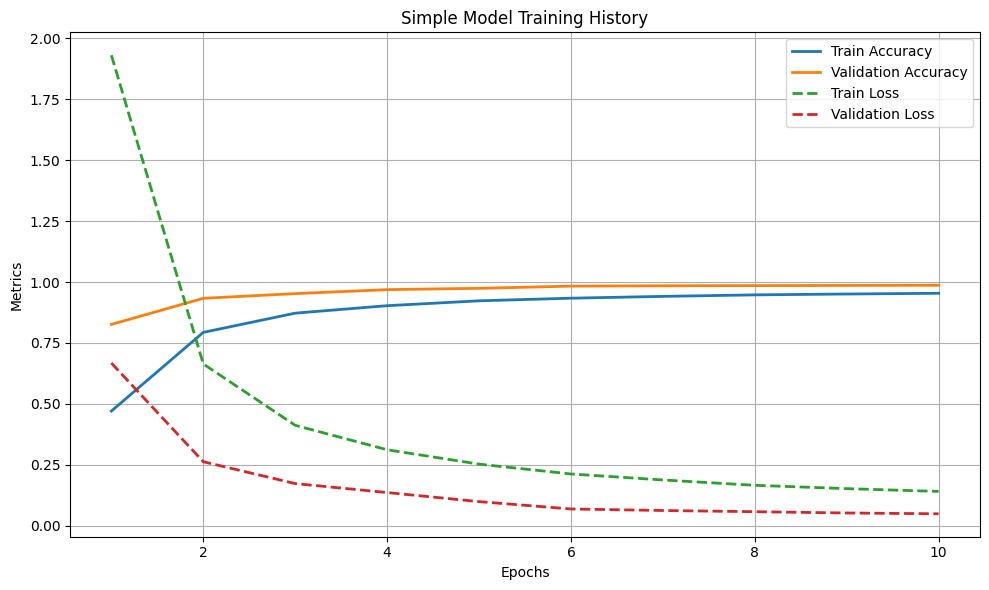

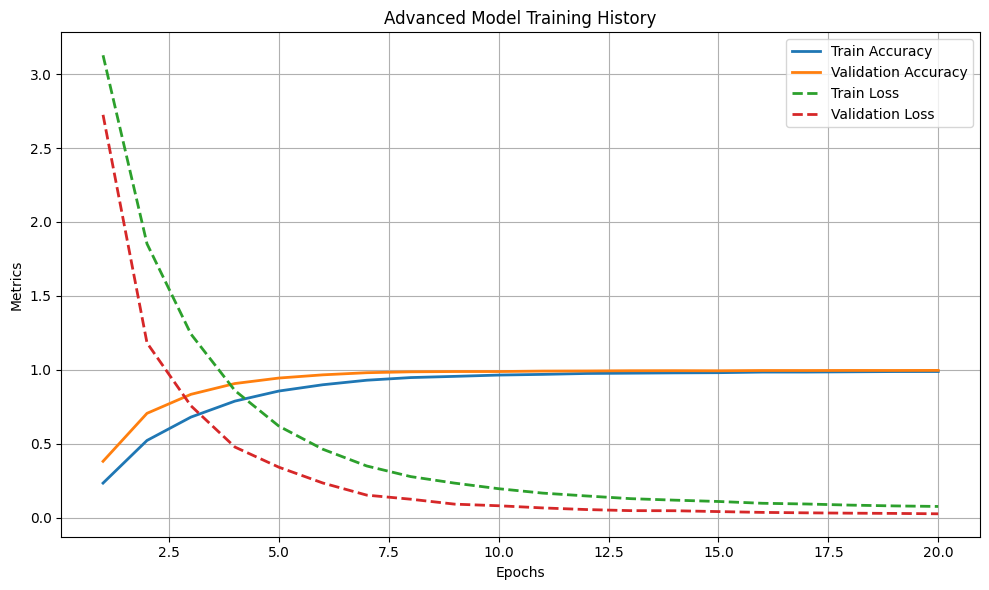

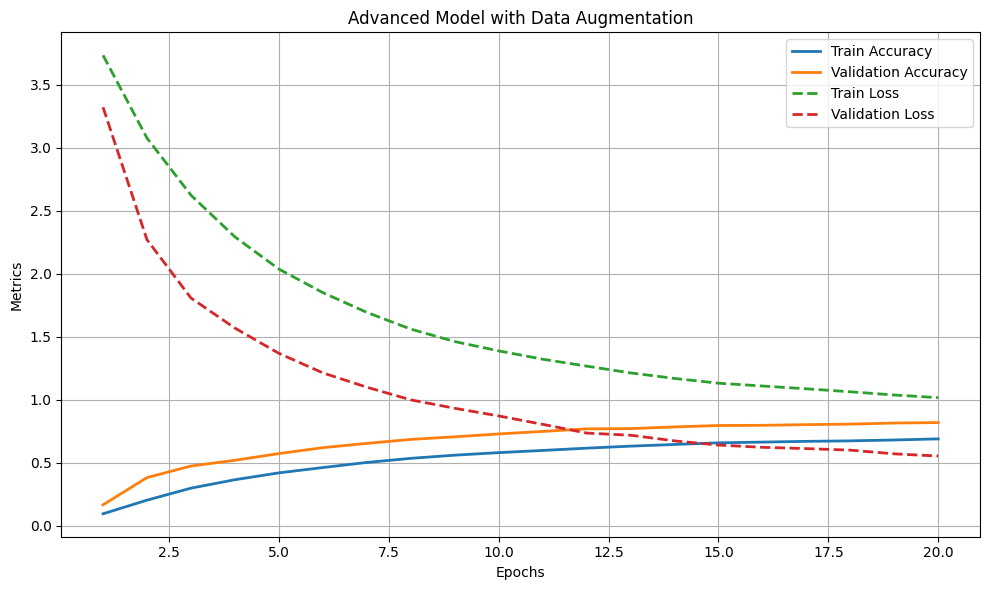

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

def plot_gtsrb_training(history, title="Model Training History"):
    """
    Plots the training history of a CNN model for the GTSRB dataset.

    Args:
        history: Keras History object from model.fit().
        title: Title for the plot.
    """
    epochs = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(10, 6))

    # Plot Train and Validation Accuracy
    plt.plot(epochs, history.history['accuracy'], label="Train Accuracy", lw=2)
    plt.plot(epochs, history.history['val_accuracy'], label="Validation Accuracy", lw=2)

    # Plot Train and Validation Loss
    plt.plot(epochs, history.history['loss'], label="Train Loss", lw=2, linestyle="--")
    plt.plot(epochs, history.history['val_loss'], label="Validation Loss", lw=2, linestyle="--")

    plt.xlabel("Epochs")
    plt.ylabel("Metrics")
    plt.title(title)  # Utilisation du titre passé en argument
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Appels avec des titres différents
plot_gtsrb_training(history_simple, title="Simple Model Training History")
plot_gtsrb_training(history_advanced, title="Advanced Model Training History")
plot_gtsrb_training(history_advanced_data_augmented, title="Advanced Model with Data Augmentation")


- Modèle Simple : Ce modèle converge rapidement avec une accuracy d’entraînement et de validation proche de 0.95-0.99. La perte diminue de manière stable, mais la validation étant légèrement supérieure à l’entraînement, un début de sur-apprentissage est possible.

- Modèle avancé sans augmentation : L’apprentissage est plus progressif et stable, avec une accuracy autour de 0.98-0.99 et une perte qui diminue continuellement. Il montre une bonne généralisation sans signe évident de sur-apprentissage.

- Modèle avancé avec augmentation : L’augmentation de données ralentit l’apprentissage, mais améliore la robustesse du modèle. L’accuracy d’entraînement progresse lentement et reste inférieure à la validation pendant une grande partie du processus.

**Conclusion globale** : Le modèle avancé sans augmentation offre un bon équilibre entre performance et stabilité, tandis que l’augmentation de données apporte une meilleure généralisation au prix d’un apprentissage plus lent. Le choix du modèle dépendra du besoin en robustesse face à des données variées et du temps d'entraînement disponible.

# **5️⃣ - Evaluation du modèle**

Nous avons évalué les performances des modèles simple et avancé sans augmentation en utilisant une validation croisée à 5 plis (K-Fold Cross Validation).

Cette méthode permet d’obtenir une estimation plus fiable des performances en entraînant et testant le modèle sur différentes portions du dataset.

Après chaque entraînement, nous avons calculé les métriques clés (accuracy, précision, rappel, F1-score) pour comparer les performances des deux modèles.

**◾ Modèle simple :**

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

#Evaluation model_simple

model = model_simple

#Set number of folds for K-Fold Cross Validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

#Initialize lists to store results
epochs = 5
fold_no = 1
f1_scores = []
recalls = []
precisions = []
accuracies = []

for train_index, val_index in kf.split(X):
    print(f"\nTraining fold {fold_no}/{k}...")

#Split the data for this fold
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]


#Fit the model
    history=model.fit(X_train, y_train, epochs=epochs, batch_size=64, validation_data=(X_val, y_val), verbose=1)

#Evaluate the model
    y_pred = model.predict(X_val)

#Get the predicted labels
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_val, axis=1)

#Calculate classification metrics
    report = classification_report(y_true_labels, y_pred_labels, output_dict=True)

    f1_scores.append(report['accuracy'])  # Store F1 score
    recalls.append(report['macro avg']['recall'])  # Store recall score
    precisions.append(report['macro avg']['precision'])  # Store precision score
    accuracies.append(report['accuracy'])  # Store accuracy score

    fold_no += 1

# Stockages des métriques
    F1_simple = np.mean(f1_scores)
    Recall_simple = np.mean(recalls)
    Precision_simple = np.mean(precisions)
    Accuracy_simple = np.mean(accuracies)

#Print the average results after all folds
print("\nAverage Results:")
print(f"F1 Score: {np.mean(f1_scores)}")
print(f"Recall: {np.mean(recalls)}")
print(f"Precision: {np.mean(precisions)}")
print(f"Accuracy: {np.mean(accuracies)}")


Training fold 1/5...
Epoch 1/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9856 - loss: 0.0433 - val_accuracy: 0.9995 - val_loss: 0.0023
Epoch 2/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9858 - loss: 0.0413 - val_accuracy: 0.9992 - val_loss: 0.0036
Epoch 3/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9873 - loss: 0.0365 - val_accuracy: 0.9995 - val_loss: 0.0031
Epoch 4/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9896 - loss: 0.0322 - val_accuracy: 0.9992 - val_loss: 0.0038
Epoch 5/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9874 - loss: 0.0348 - val_accuracy: 0.9991 - val_loss: 0.0040
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Training fold 2/5...
Epoch 1/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9889 - loss: 0.0360 - val_accuracy: 0.9999 - val_loss: 0.0015
Epoch 2/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9879 - loss: 0.0347 - val_accuracy: 0.9996 - val_loss: 0.0016
Epoch 3/5
491/491 ━━━━━━━━

**➡️ Analyse :**

L'entraînement du modèle simple avec validation croisée (K=5) montre des performances très élevées et stables sur chaque fold :

- Accuracy très haute sur chaque fold, dépassant 0.99 en validation dès les premières époques.
- Perte très faible, indiquant une bonne convergence et une minimisation des erreurs.
- Faible variabilité entre les folds, suggérant que le modèle généralise bien sur l’ensemble des données.

Le modèle simple atteint un très haut niveau de précision, ce qui peut indiquer un risque de sur-apprentissage si les données sont trop similaires entre les folds. Une analyse plus approfondie sur la matrice de confusion et les erreurs spécifiques serait pertinente pour s’assurer que le modèle ne sur-apprend pas certains patterns du dataset

**◾ Modèle avancé :**

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

#Evaluation model_advanced

model = model_advanced

#Set number of folds for K-Fold Cross Validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

#Initialize lists to store results
epochs = 5
fold_no = 1
f1_scores = []
recalls = []
precisions = []
accuracies = []

for train_index, val_index in kf.split(X):
    print(f"\nTraining fold {fold_no}/{k}...")

    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]


    history=model.fit(X_train, y_train, epochs=epochs, batch_size=64, validation_data=(X_val, y_val), verbose=1)

#Evaluate the model
    y_pred = model.predict(X_val)

    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_val, axis=1)

#Calculate classification metrics
    report = classification_report(y_true_labels, y_pred_labels, output_dict=True)

    f1_scores.append(report['accuracy'])
    recalls.append(report['macro avg']['recall'])
    precisions.append(report['macro avg']['precision'])
    accuracies.append(report['accuracy'])

    fold_no += 1

# Stockages des métriques
    F1_advanced = np.mean(f1_scores)
    Recall_advanced = np.mean(recalls)
    Precision_advanced = np.mean(precisions)
    Accuracy_advanced = np.mean(accuracies)

#Print the average results after all folds
print("\nAverage Results:")
print(f"F1 Score: {np.mean(f1_scores)}")
print(f"Recall: {np.mean(recalls)}")
print(f"Precision: {np.mean(precisions)}")
print(f"Accuracy: {np.mean(accuracies)}")


Training fold 1/5...
Epoch 1/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.7789 - loss: 0.7442 - val_accuracy: 0.8513 - val_loss: 0.5039
Epoch 2/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8101 - loss: 0.6663 - val_accuracy: 0.8755 - val_loss: 0.4599
Epoch 3/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8304 - loss: 0.6100 - val_accuracy: 0.9022 - val_loss: 0.3871
Epoch 4/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8553 - loss: 0.5363 - val_accuracy: 0.9153 - val_loss: 0.3451
Epoch 5/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8708 - loss: 0.4947 - val_accuracy: 0.9310 - val_loss: 0.3006
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Training fold 2/5...
Epoch 1/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8860 - loss: 0.4527 - val_accuracy: 0.9417 - val_loss: 0.2531
Epoch 2/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8981 - loss: 0.4156 - val_accuracy: 0.9473 - val_loss: 0.2325
Epoch 3/5
491/491 ━━━━━━

**➡️ Analyse :**

L'entraînement du modèle avancé avec validation croisée (K=5) montre des performances extrêmement élevées et cohérentes sur chaque fold :

- Accuracy moyenne de 99.88%, avec très peu de variation entre les folds.
- Perte de validation extrêmement faible (~0.005), indiquant que le modèle s'ajuste très bien aux données.
- F1-score, Précision et Rappel > 99.8%, ce qui montre une excellente capacité de classification sans déséquilibre notable.

Le modèle avancé atteint une quasi-perfection en validation, suggérant qu'il s’adapte très bien au dataset. Cependant, une précision aussi élevée pourrait indiquer un sur-apprentissage, surtout si les données de test diffèrent des données d’entraînement

### **◾ Matrice de confusion**

Nous avons généré la matrice de confusion pour analyser les performances du modèle avancé en visualisant les erreurs de classification.

Cette matrice permet d'identifier quelles classes sont le plus souvent confondues et d’évaluer les points faibles du modèle, ce qui peut guider les améliorations futures.

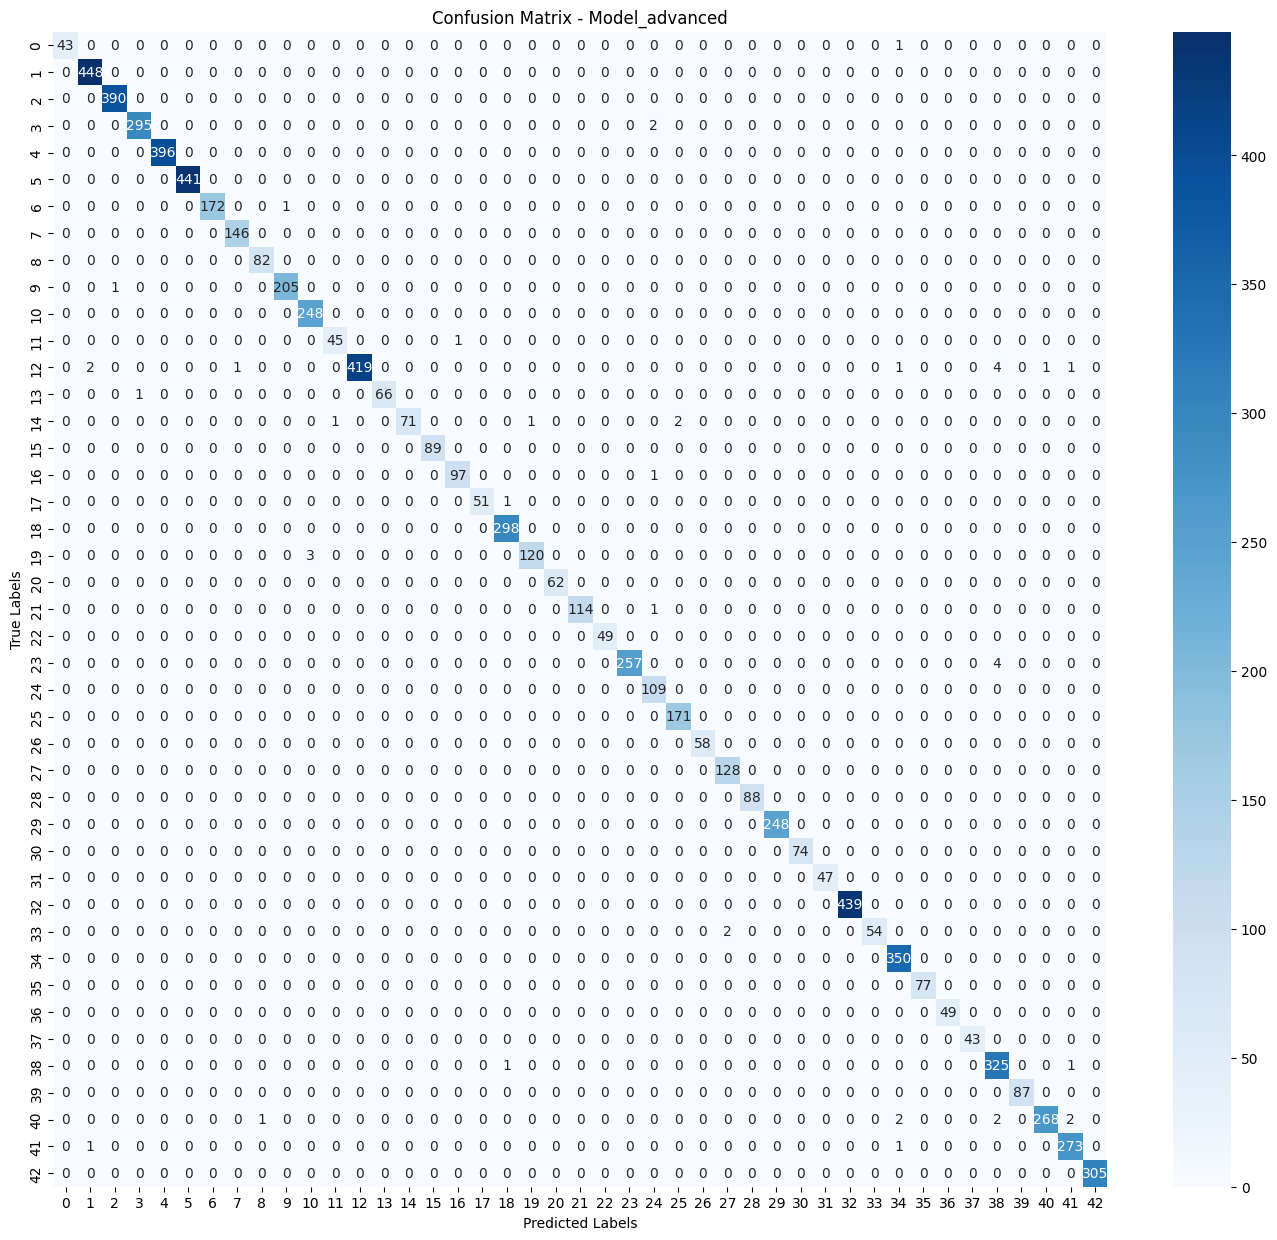

In [ ]:
# Modèle avancé

conf_matrix = confusion_matrix(y_true_labels, y_pred_labels)

# Plot confusion matrix
plt.figure(figsize=(17, 15))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_true_labels), yticklabels=np.unique(y_true_labels))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title(f'Confusion Matrix - Model_advanced')
plt.show()

**➡️ Analyse :**

Le modèle avancé affiche une très bonne performance, avec une majorité des prédictions bien alignées sur la diagonale de la matrice de confusion, confirmant une haute précision et un taux d’accuracy proche de 99 %.

Toutefois, quelques confusions subsistent entre certaines classes, probablement en raison de similarités visuelles ou d’un déséquilibre des données.

Une analyse plus fine des erreurs, via Grad-CAM ou une augmentation ciblée des données, pourrait encore améliorer la robustesse du modèle.



### **◾ Comparaison des performances des différents modèles**

Nous avons comparé les performances des modèles simple et avancé en affichant un tableau récapitulatif des principales métriques (F1-score, recall, précision, accuracy).

Un graphique comparatif a également été généré pour visualiser les écarts entre les deux modèles et identifier celui offrant les meilleures performances globales.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#Valeurs des métriques calculées

F1_simple = F1_simple
Recall_simple = Recall_simple
Precision_simple = Precision_simple
Accuracy_simple = Accuracy_simple

F1_advanced = F1_advanced
Recall_advanced = Recall_advanced
Precision_advanced = Precision_advanced
Accuracy_advanced = Accuracy_advanced

#Données extraites du document
data = {
    "Modèle": ["Simple", "Avancé"],
    "F1 Score": [F1_simple, F1_advanced],
    "Recall": [Recall_simple, Recall_advanced],
    "Precision": [Precision_simple, Precision_advanced],
    "Accuracy": [Accuracy_simple, Accuracy_advanced]
}

#DataFrame
df_metrics = pd.DataFrame(data)

# Vérification que les données sont bien numériques
if df_metrics.iloc[:, 1:].isnull().values.any():
    print("Erreur: Certaines métriques ne sont pas définies")
else:
    # Affichage du tableau
    print(df_metrics)




   Modèle  F1 Score    Recall  Precision  Accuracy
0  Simple  0.999286  0.998662   0.999367  0.999286
1  Avancé  0.972991  0.953216   0.976643  0.972991


### **Jeu de test - prétraitement**

In [ ]:
dataset_path2 = "/root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/test"
print("Contenu du dossier test :")
print(os.listdir(dataset_path))


dataset_path=dataset_path2

#Définition de la taille des images
IMG_SIZE = (32, 32)

image_paths = []
labels = []


#Récupération des chemins des images et des labels
for class_label, class_name in enumerate(sorted(os.listdir(dataset_path))):
    class_dir = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_dir):
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            image_paths.append(img_path)
            labels.append(class_label)

#Chargement des images et prétraitement
X_test, y_test = [], []
for img_path, label in zip(image_paths, labels):
    if os.path.exists(img_path):
        img = Image.open(img_path).convert('RGB')  # Conversion en RGB
        img = img.resize(IMG_SIZE)  # Redimensionnement
        X_test.append(np.array(img))  # Conversion en tableau NumPy
        y_test.append(label)

#Conversion en tableaux NumPy et normalisation
X_test = np.array(X_test) / 255.0  # Normalisation des pixels
y_test = np.array(y_test)
y_test = to_categorical(y, num_classes=len(set(y_test)))  # Encodage one-hot des labels

print("Shape du dataset:", X.shape, y.shape)

Contenu du dossier test :
['13', '11', '10', '22', '38', '5', '8', '27', '12', '9', '40', '37', '16', '29', '18', '1', '24', '0', '39', '33', '35', '21', '17', '34', '30', '32', '26', '19', '25', '2', '6', '41', '28', '42', '14', '23', '31', '3', '20', '15', '36', '4', '7']
Shape du dataset: (39209, 32, 32, 3) (39209, 43)


### **◾ Evaluation du modèle avancé sur le jeu de test**

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical


print(f"Test: {X_test.shape}, {y_test.shape}")

# 2️⃣ Normalisation des jeux de données (diviser par 255 pour mettre les pixels entre 0 et 1)

X_test = X_test / 255.0

# 3️⃣ Vérifier que y_test est bien au bon format
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_test_labels = np.argmax(y_test, axis=1)  # Convertir one-hot en labels entiers
else:
    y_test_labels = y_test  # Si déjà sous forme d'entiers, ne rien changer

print(f"Exemple y_test_labels (vérités terrain) : {y_test_labels[:10]}")

# 4️⃣ Vérification du modèle avant la prédiction
if not hasattr(model_advanced, 'predict'):
    raise ValueError("Erreur : Le modèle avancé n'est pas correctement défini ou entraîné.")

# 5️⃣ Prédictions sur le jeu de test
y_pred_labels = model_advanced.predict(X_test)

# 6️⃣ Conversion des probabilités en classes
y_pred_labels = np.argmax(y_pred, axis=1)

print(f"Exemple y_pred_labels (prédictions) : {y_pred_labels[:10]}")

# 7️⃣ Vérification des classes uniques pour éviter les erreurs dans la matrice de confusion
unique_classes = np.unique(np.concatenate((y_test_labels, y_pred_labels)))

# 8️⃣ Calcul des métriques de performance
print("🔍 Rapport de classification sur le jeu de test :\n")
print(classification_report(y_test_labels, y_pred_labels, digits=4))

# 9️⃣ Affichage de la matrice de confusion
conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)

#  🔟 Visualisation de la matrice de confusion
plt.figure(figsize=(15, 12))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_classes,
            yticklabels=unique_classes)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Model Avancé (Test Set)')
plt.show()




Test: (0,), (39209, 43, 2)
Exemple y_test_labels (vérités terrain) : [[1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]]


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


ValueError: math domain error

# **6️⃣ - Améliorations et Expérimentations**

# **7️⃣ - Interprétation et Visualisation des Résultats**

In [32]:
dummy_input = np.random.rand(1, 32, 32, 3).astype(np.float32)  # Ensure the shape matches the model's input
_ = model_simple(dummy_input)  # This initializes the model


In [27]:
layer_outputs = [
    layer.output for layer in model_simple.layers if isinstance(layer, tf.keras.layers.Conv2D)
]
print("Number of Conv2D layers:", len(layer_outputs))  # Debugging step


Number of Conv2D layers: 2


In [28]:
from tensorflow.keras.layers import Input
input_tensor = Input(shape=(32, 32, 3))  # Define the input shape
activation_model = Model(inputs=input_tensor, outputs=layer_outputs)


In [33]:
print(model_simple.input)  # If this prints `None`, the model hasn't been properly initialized


AttributeError: The layer sequential has never been called and thus has no defined input.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model



# Extract activations
layer_outputs = [layer.output for layer in model_simple.layers if isinstance(layer, tf.keras.layers.Conv2D)]


activation_model = Model(inputs=model_simple.input, outputs=layer_outputs)

# Choose an image from your dataset
img = X[0]  # Assuming X contains your images
img = np.expand_dims(img, axis=0)  # Add batch dimension

# Get activations
activations = activation_model.predict(img)

# Plot activations
layer_names = [layer.name for layer in model_simple.layers if isinstance(layer, tf.keras.layers.Conv2D)]
for layer_name, activation in zip(layer_names, activations):
    num_filters = activation.shape[-1]
    fig, axes = plt.subplots(1, min(num_filters, 5), figsize=(10, 5))  # Show only 5 filters
    fig.suptitle(layer_name)
    for i in range(min(num_filters, 5)):
        axes[i].imshow(activation[0, :, :, i], cmap='viridis')
        axes[i].axis('off')
    plt.show()  # Corrected


AttributeError: The layer sequential has never been called and thus has no defined input.